    # Експеримент A: BERT Fake News Detector — Дисбаланс класів

## Мета: дослідити вплив дисбалансу (100% TRUE + 50% FAKE)

- **Датасет**: 100% TRUE + 50% FAKE (random_state=42)
- **Архітектури**: ті самі 3 голови що в 02
- **Гіперпараметри**: ідентичні до базового експерименту
- **Чекпойнти**: збереження після кожної епохи для можливості продовження

## 1. Імпорти та налаштування

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizerFast,
    BertModel,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Device: {device}')

import gc
torch.cuda.empty_cache()
gc.collect()

PyTorch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.4 GB
Device: cuda


109

## 2. Гіперпараметри

In [2]:
DATA_PATH   = r'C:\Users\igrew\OneDrive\Desktop\Course Work\Datasets\news_detector\FINAL_DATASET.csv'
MODELS_DIR  = 'models'
PLOTS_DIR   = os.path.join('plots', '03')  
RESULTS_DIR = 'results'
CHECKPOINTS_DIR = 'checkpoints'          

os.makedirs(MODELS_DIR,      exist_ok=True)
os.makedirs(PLOTS_DIR,       exist_ok=True)
os.makedirs(RESULTS_DIR,     exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

assert os.path.exists(DATA_PATH), f'Датасет не знайдено: {DATA_PATH}'

MODEL_NAME    = 'bert-base-multilingual-cased'
MAX_LEN       = 256
BATCH_SIZE    = 16
NUM_EPOCHS    = 3
LEARNING_RATE = 1e-5
WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.1
DROPOUT_RATE  = 0.4
GRADIENT_CLIP = 1.0
SEED          = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Гіперпараметри:')
print(f'  MAX_LEN={MAX_LEN} | BATCH_SIZE={BATCH_SIZE} | EPOCHS={NUM_EPOCHS}')
print(f'  LR={LEARNING_RATE} | DROPOUT={DROPOUT_RATE} | CLIP={GRADIENT_CLIP}')
print(f'  PLOTS_DIR: {PLOTS_DIR}')
print(f'  CHECKPOINTS_DIR: {CHECKPOINTS_DIR}')

Гіперпараметри:
  MAX_LEN=256 | BATCH_SIZE=16 | EPOCHS=3
  LR=1e-05 | DROPOUT=0.4 | CLIP=1.0
  PLOTS_DIR: plots\03
  CHECKPOINTS_DIR: checkpoints


## 3. Формування незбалансованого датасету

Повний датасет: (21738, 2)
Розподіл: {0: 10869, 1: 10869}

Експеримент A (незбалансований датасет):
  TRUE: 10869 (100%)
  FAKE: 5434 (50% від оригінальних)
  Всього: 16303
  Співвідношення TRUE/FAKE: 2.00


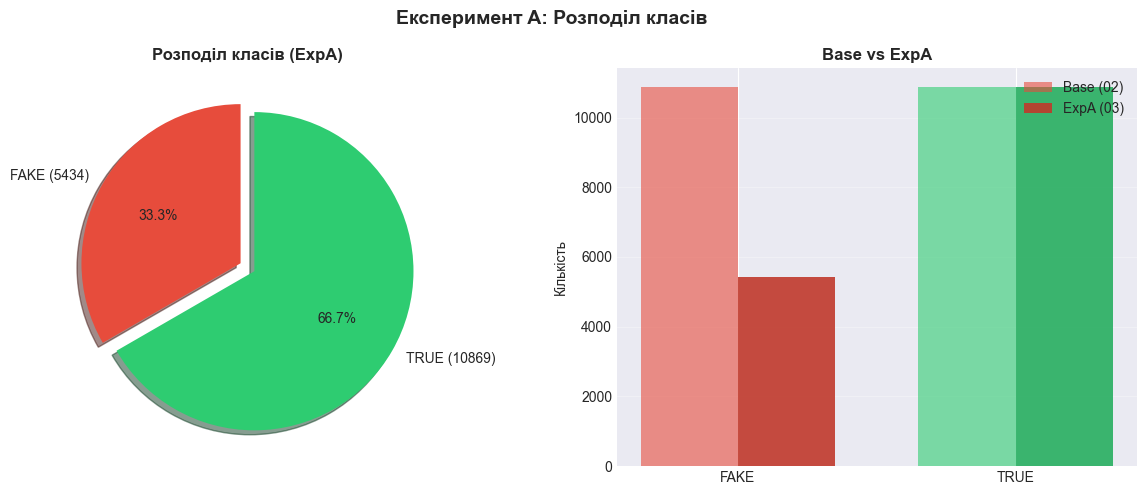

In [3]:
df_full = pd.read_csv(DATA_PATH)
df_full = df_full.dropna(subset=['text', 'label'])

print(f'Повний датасет: {df_full.shape}')
print(f'Розподіл: {df_full["label"].value_counts().to_dict()}')

# 100% TRUE + 50% FAKE
df_true = df_full[df_full['label'] == 1]
df_fake = df_full[df_full['label'] == 0].sample(frac=0.5, random_state=SEED)

df = pd.concat([df_true, df_fake]).sample(frac=1, random_state=SEED).reset_index(drop=True)

true_count = (df['label'] == 1).sum()
fake_count = (df['label'] == 0).sum()

print(f'\nЕксперимент A (незбалансований датасет):')
print(f'  TRUE: {true_count} (100%)')
print(f'  FAKE: {fake_count} (50% від оригінальних)')
print(f'  Всього: {len(df)}')
print(f'  Співвідношення TRUE/FAKE: {true_count/fake_count:.2f}')

# Візуалізація нового розподілу
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Експеримент A: Розподіл класів', fontsize=14, fontweight='bold')

axes[0].pie([fake_count, true_count],
            labels=[f'FAKE ({fake_count})', f'TRUE ({true_count})'],
            colors=['#e74c3c','#2ecc71'], autopct='%1.1f%%',
            startangle=90, explode=(0.05,0.05), shadow=True)
axes[0].set_title('Розподіл класів (ExpA)', fontweight='bold')

# Порівняння з базовим
orig_fake = (df_full['label'] == 0).sum()
orig_true = (df_full['label'] == 1).sum()
x = np.arange(2)
w = 0.35
axes[1].bar(x - w/2, [orig_fake, orig_true], w, label='Base (02)', color=['#e74c3c','#2ecc71'], alpha=0.6)
axes[1].bar(x + w/2, [fake_count, true_count], w, label='ExpA (03)', color=['#c0392b','#27ae60'], alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['FAKE', 'TRUE'])
axes[1].set_title('Base vs ExpA', fontweight='bold')
axes[1].set_ylabel('Кількість')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_dataset_expA_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Split та токенізація

In [4]:
X = df['text'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'Train:      {len(X_train):>6} ({len(X_train)/len(X)*100:.1f}%) | FAKE={np.sum(y_train==0)} TRUE={np.sum(y_train==1)}')
print(f'Validation: {len(X_val):>6} ({len(X_val)/len(X)*100:.1f}%) | FAKE={np.sum(y_val==0)} TRUE={np.sum(y_val==1)}')
print(f'Test:       {len(X_test):>6} ({len(X_test)/len(X)*100:.1f}%) | FAKE={np.sum(y_test==0)} TRUE={np.sum(y_test==1)}')

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
print(f'\nТокенізатор: {type(tokenizer).__name__}')

Train:       11412 (70.0%) | FAKE=3804 TRUE=7608
Validation:   2445 (15.0%) | FAKE=815 TRUE=1630
Test:         2446 (15.0%) | FAKE=815 TRUE=1631

Токенізатор: BertTokenizer


In [5]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

train_dataset = NewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = NewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = NewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_loader)} батчів | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train: 714 батчів | Val: 153 | Test: 153


## 5. Архітектури (ідентичні до 02)

In [6]:
class BertClassifierHeadA(nn.Module):
    def __init__(self, bert_model_name, num_classes=2, dropout=0.4):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

class BertClassifierHeadB(nn.Module):
    def __init__(self, bert_model_name, num_classes=2, dropout=0.4):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 512), nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, num_classes))

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])

class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, hidden_states, attention_mask):
        scores = self.attention(hidden_states).squeeze(-1)
        scores = scores.masked_fill(attention_mask == 0, float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (hidden_states * weights).sum(dim=1)

class BertClassifierHeadC(nn.Module):
    def __init__(self, bert_model_name, num_classes=2, dropout=0.4):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden = self.bert.config.hidden_size
        self.attention_pool = AttentionPooling(hidden)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256), nn.LayerNorm(256),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, num_classes))

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.attention_pool(out.last_hidden_state, attention_mask))

print('Архітектури визначено (ідентичні до 02)')

Архітектури визначено (ідентичні до 02)


## 6. Функції тренування з чекпойнтами

In [7]:
def save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_f1, model_name):
    """Зберігає чекпойнт після кожної епохи — можна продовжити навчання"""
    ckpt_path = os.path.join(CHECKPOINTS_DIR, f'{model_name}_epoch{epoch}_ckpt.pt')
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history':              history,
        'best_val_f1':          best_val_f1,
        'hyperparameters': {
            'max_len': MAX_LEN, 'batch_size': BATCH_SIZE,
            'lr': LEARNING_RATE, 'dropout': DROPOUT_RATE
        }
    }, ckpt_path)
    return ckpt_path


def load_checkpoint(model, optimizer, scheduler, model_name, epoch):
    """Завантажує чекпойнт для продовження навчання"""
    ckpt_path = os.path.join(CHECKPOINTS_DIR, f'{model_name}_epoch{epoch}_ckpt.pt')
    if not os.path.exists(ckpt_path):
        print(f'Чекпойнт не знайдено: {ckpt_path}')
        return None, None
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    print(f'Завантажено чекпойнт: epoch={ckpt["epoch"]}, best_f1={ckpt["best_val_f1"]:.4f}')
    return ckpt['history'], ckpt['best_val_f1']


def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc='  Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    return avg_loss, accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average='weighted')


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()
            all_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    return avg_loss, accuracy_score(all_labels, all_preds), \
           f1_score(all_labels, all_preds, average='weighted'), \
           np.array(all_labels), np.array(all_preds), np.array(all_probs)


def train_model(model, train_loader, val_loader, model_name, resume_from_epoch=None):
    """
    Тренування з чекпойнтами.
    resume_from_epoch: якщо вказати номер епохи — продовжить з того чекпойнту
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    total_steps  = len(train_loader) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'train_f1':[], 'val_f1':[]}
    best_val_f1 = 0
    start_epoch = 1

    # Завантаження чекпойнту якщо треба продовжити
    if resume_from_epoch is not None:
        loaded_history, loaded_f1 = load_checkpoint(model, optimizer, scheduler, model_name, resume_from_epoch)
        if loaded_history is not None:
            history = loaded_history
            best_val_f1 = loaded_f1
            start_epoch = resume_from_epoch + 1
            print(f'Продовження з епохи {start_epoch}')

    best_path = os.path.join(MODELS_DIR, f'bert_fake_{model_name.lower()}_expA_best.pt')

    print(f'\nТренування {model_name} (ExpA)...')
    print(f'   Кроків warmup: {warmup_steps} / {total_steps}')
    print('=' * 80)
    print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"Val F1":>6}')
    print('=' * 80)

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        flag = ''
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_path)
            flag = ' ✓ SAVED'

        # Зберігаємо чекпойнт після КОЖНОЇ епохи
        ckpt_path = save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_f1, model_name)

        delta = val_loss - train_loss
        print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>6.4f}  Δ={delta:+.4f}{flag}')
        print(f'         Чекпойнт: {ckpt_path}')

    print('=' * 80)
    print(f'Найкращий Val F1: {best_val_f1:.4f}')
    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, history, best_val_f1

print('Функції тренування з чекпойнтами визначено')
print('Для продовження навчання: train_model(model, ..., resume_from_epoch=N)')

Функції тренування з чекпойнтами визначено
Для продовження навчання: train_model(model, ..., resume_from_epoch=N)


## 7. Функції візуалізації

In [8]:
def plot_head_results(head_name, history, y_true, y_pred, y_prob, metrics, prefix='03'):
    epochs = range(1, len(history['train_loss']) + 1)
    colors = {'A': ('#3498db','#85c1e9'), 'B': ('#e74c3c','#f1948a'), 'C': ('#2ecc71','#82e0aa')}
    letter = head_name[-1]
    c_dark, c_light = colors.get(letter, ('#3498db','#85c1e9'))

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Результати {head_name} — Експеримент A (50% FAKE)', fontsize=16, fontweight='bold')

    # Loss
    axes[0,0].plot(epochs, history['train_loss'], 'o-', color=c_dark,  label='Train', linewidth=2)
    axes[0,0].plot(epochs, history['val_loss'],   's--', color=c_light, label='Val',   linewidth=2)
    axes[0,0].set_title('Loss', fontweight='bold')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
    axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    # Accuracy
    axes[0,1].plot(epochs, history['train_acc'], 'o-', color=c_dark,  label='Train', linewidth=2)
    axes[0,1].plot(epochs, history['val_acc'],   's--', color=c_light, label='Val',   linewidth=2)
    axes[0,1].set_title('Accuracy', fontweight='bold')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
    axes[0,1].set_ylim([0.5, 1.0]); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    # Delta
    deltas = [v - t for v, t in zip(history['val_loss'], history['train_loss'])]
    bar_colors = ['#e74c3c' if d > 0.05 else '#2ecc71' for d in deltas]
    axes[0,2].bar(epochs, deltas, color=bar_colors, alpha=0.8)
    axes[0,2].axhline(y=0.05, color='orange', linestyle='--', linewidth=1.5, label='Поріг 0.05')
    axes[0,2].axhline(y=0,    color='black',  linestyle='-',  linewidth=0.8)
    for ep, d in zip(epochs, deltas):
        axes[0,2].text(ep, d + 0.002, f'{d:+.4f}', ha='center', fontsize=9)
    axes[0,2].set_title('Δ Val−Train Loss по епохах', fontweight='bold')
    axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylabel('Val Loss − Train Loss')
    axes[0,2].legend(); axes[0,2].grid(alpha=0.3, axis='y')

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[1,0], cmap='Blues',
                xticklabels=['FAKE','TRUE'], yticklabels=['FAKE','TRUE'],
                linewidths=1, linecolor='white')
    axes[1,0].set_title(f'Confusion Matrix (Acc={metrics["acc"]:.3f})', fontweight='bold')
    axes[1,0].set_xlabel('Передбачено'); axes[1,0].set_ylabel('Реальне')

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1,1].plot(fpr, tpr, color=c_dark, lw=2, label=f'AUC = {metrics["roc_auc"]:.3f}')
    axes[1,1].plot([0,1],[0,1], 'k--', lw=1, label='Random')
    axes[1,1].set_title('ROC Curve', fontweight='bold')
    axes[1,1].set_xlabel('FPR'); axes[1,1].set_ylabel('TPR')
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

    # Метрики
    metric_names  = ['Accuracy','F1','Precision','Recall','ROC-AUC']
    metric_values = [metrics['acc'], metrics['f1'], metrics['prec'], metrics['rec'], metrics['roc_auc']]
    bars = axes[1,2].bar(metric_names, metric_values, color=c_dark, alpha=0.8)
    axes[1,2].set_ylim([0, 1.05])
    axes[1,2].set_title('Метрики на тестовій вибірці', fontweight='bold')
    axes[1,2].grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, metric_values):
        axes[1,2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    save_path = os.path.join(PLOTS_DIR, f'{prefix}_bert_fake_{head_name.lower()}_expA_results.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Збережено: {save_path}')

print('Функції візуалізації визначено')

Функції візуалізації визначено


## 8. Тренування Head A (ExpA)

In [9]:
torch.cuda.empty_cache(); gc.collect()

print('=' * 60)
print('HEAD A (ExpA): [CLS] → Dropout → Linear')
print('=' * 60)

model_a = BertClassifierHeadA(MODEL_NAME, dropout=DROPOUT_RATE).to(device)
print(f'Параметрів: {sum(p.numel() for p in model_a.parameters()):,}')

# Щоб продовжити з епохи N: train_model(..., resume_from_epoch=N)
model_a, history_a, best_f1_a = train_model(model_a, train_loader, val_loader, 'HeadA')

HEAD A (ExpA): [CLS] → Dropout → Linear


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметрів: 177,854,978

Тренування HeadA (ExpA)...
   Кроків warmup: 214 / 2142
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1


     1 |     0.3318 |   0.8437 |   0.2320 |  0.9108 | 0.9104  Δ=-0.0998 ✓ SAVED
         Чекпойнт: checkpoints\HeadA_epoch1_ckpt.pt


     2 |     0.1842 |   0.9229 |   0.2484 |  0.9067 | 0.9080  Δ=+0.0642
         Чекпойнт: checkpoints\HeadA_epoch2_ckpt.pt


     3 |     0.1331 |   0.9486 |   0.2598 |  0.9149 | 0.9150  Δ=+0.1267 ✓ SAVED
         Чекпойнт: checkpoints\HeadA_epoch3_ckpt.pt
Найкращий Val F1: 0.9150



Test Results Head A (ExpA):
  acc: 0.9203
  f1: 0.9206
  prec: 0.9211
  rec: 0.9203
  roc_auc: 0.9811

Classification Report:
              precision    recall  f1-score   support

        FAKE     0.8690    0.8957    0.8822       815
        TRUE     0.9471    0.9326    0.9398      1631

    accuracy                         0.9203      2446
   macro avg     0.9081    0.9141    0.9110      2446
weighted avg     0.9211    0.9203    0.9206      2446



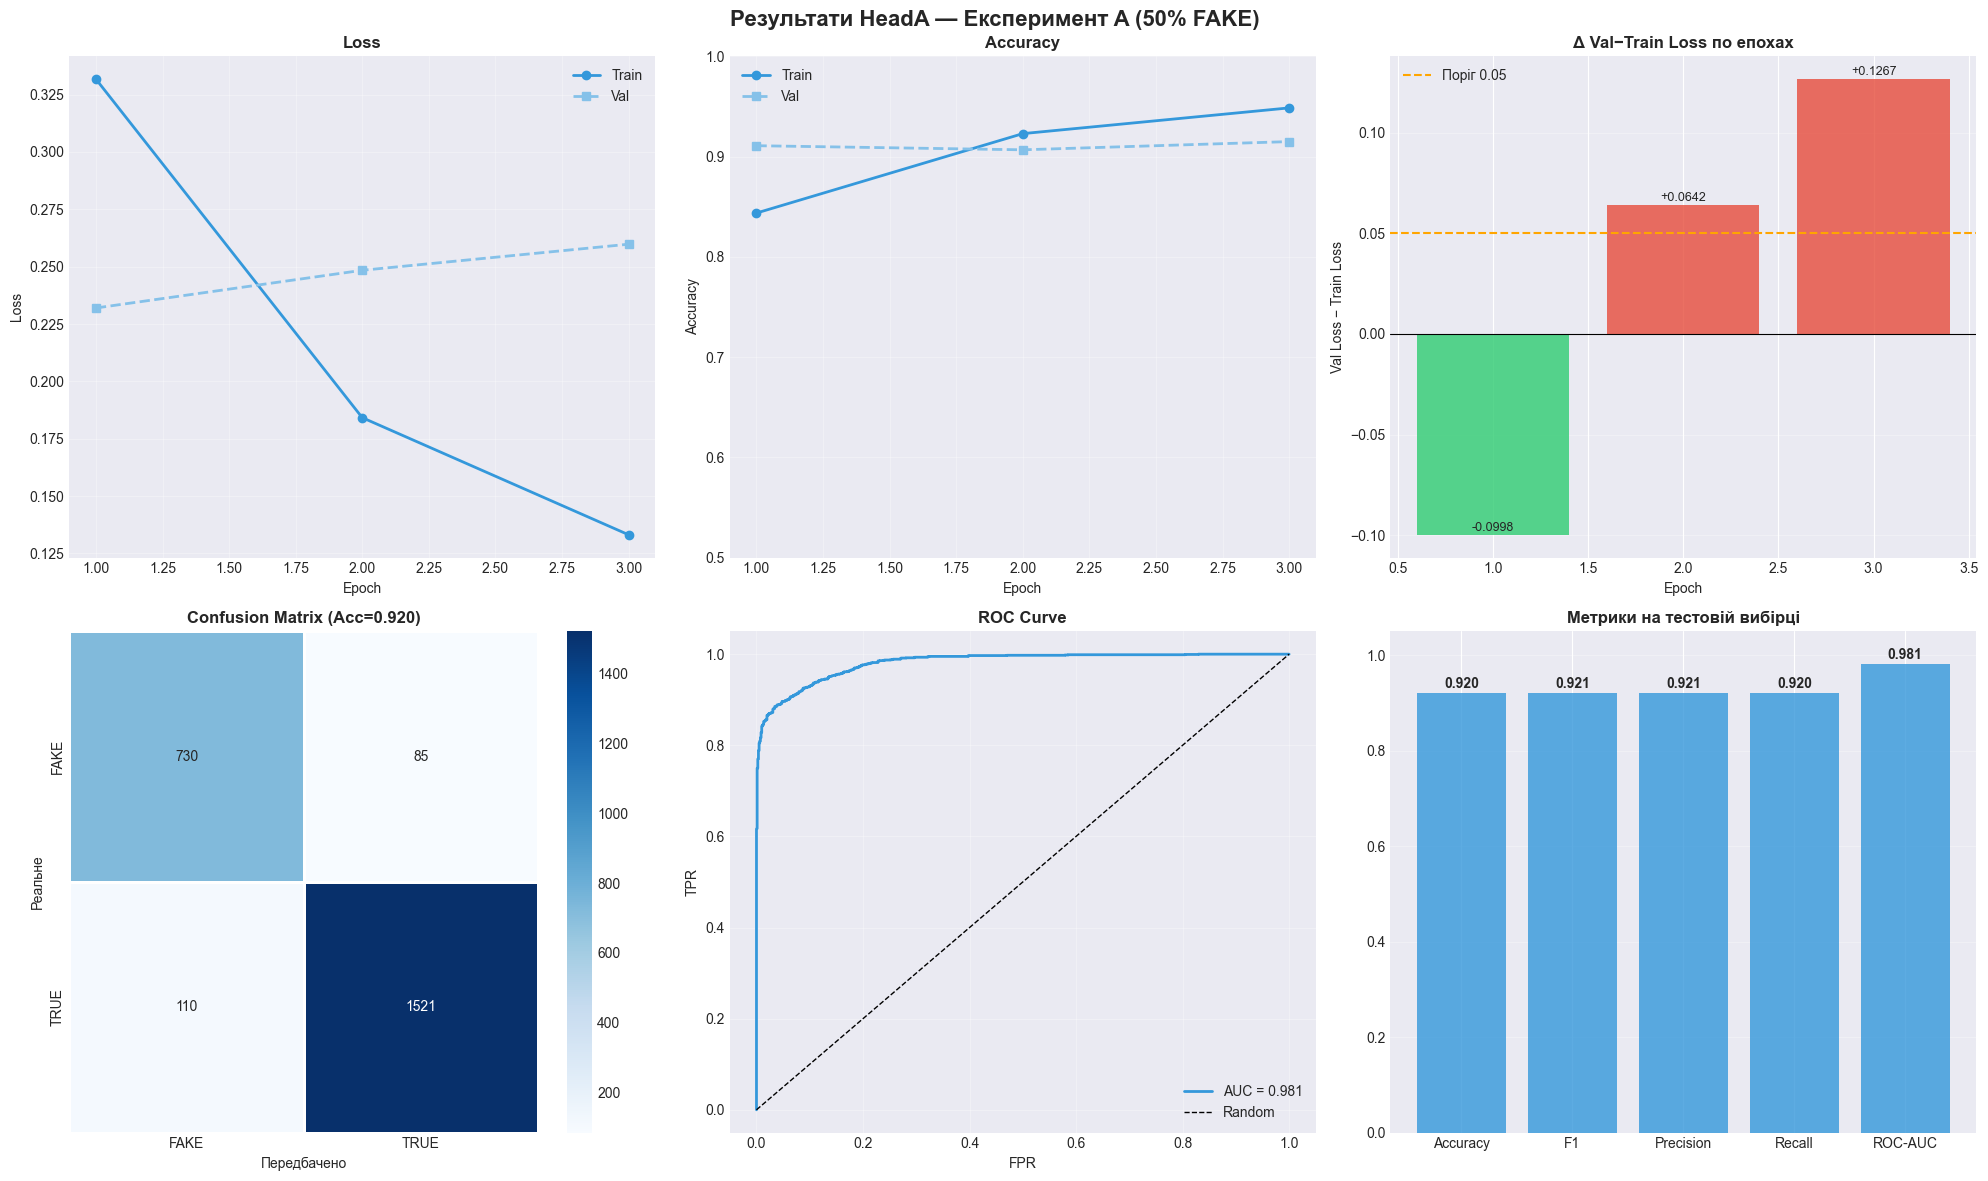

Збережено: plots\03\03_bert_fake_heada_expA_results.png


In [10]:
criterion = nn.CrossEntropyLoss()
_, _, _, y_true_a, y_pred_a, y_prob_a = evaluate(model_a, test_loader, criterion)

metrics_a = {
    'acc':     accuracy_score(y_true_a, y_pred_a),
    'f1':      f1_score(y_true_a, y_pred_a, average='weighted'),
    'prec':    precision_score(y_true_a, y_pred_a, average='weighted'),
    'rec':     recall_score(y_true_a, y_pred_a, average='weighted'),
    'roc_auc': roc_auc_score(y_true_a, y_prob_a)
}

print('\nTest Results Head A (ExpA):')
for k, v in metrics_a.items():
    print(f'  {k}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_true_a, y_pred_a, target_names=['FAKE','TRUE'], digits=4))

plot_head_results('HeadA', history_a, y_true_a, y_pred_a, y_prob_a, metrics_a)

## 9. Тренування Head B (ExpA)

In [11]:
torch.cuda.empty_cache(); gc.collect()

print('=' * 60)
print('HEAD B (ExpA): [CLS] → Linear(768→512) → BN → ReLU → Dropout → Linear(512→2)')
print('=' * 60)

model_b = BertClassifierHeadB(MODEL_NAME, dropout=DROPOUT_RATE).to(device)
print(f'Параметрів: {sum(p.numel() for p in model_b.parameters()):,}')

model_b, history_b, best_f1_b = train_model(model_b, train_loader, val_loader, 'HeadB')

HEAD B (ExpA): [CLS] → Linear(768→512) → BN → ReLU → Dropout → Linear(512→2)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметрів: 178,249,218

Тренування HeadB (ExpA)...
   Кроків warmup: 214 / 2142
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1


     1 |     0.3609 |   0.8337 |   0.2461 |  0.9018 | 0.9013  Δ=-0.1148 ✓ SAVED
         Чекпойнт: checkpoints\HeadB_epoch1_ckpt.pt


     2 |     0.2156 |   0.9185 |   0.2288 |  0.9112 | 0.9120  Δ=+0.0132 ✓ SAVED
         Чекпойнт: checkpoints\HeadB_epoch2_ckpt.pt


     3 |     0.1436 |   0.9487 |   0.2541 |  0.9190 | 0.9191  Δ=+0.1106 ✓ SAVED
         Чекпойнт: checkpoints\HeadB_epoch3_ckpt.pt
Найкращий Val F1: 0.9191



Test Results Head B (ExpA):
  acc: 0.9272
  f1: 0.9274
  prec: 0.9277
  rec: 0.9272
  roc_auc: 0.9807

Classification Report:
              precision    recall  f1-score   support

        FAKE     0.8824    0.9018    0.8920       815
        TRUE     0.9504    0.9399    0.9451      1631

    accuracy                         0.9272      2446
   macro avg     0.9164    0.9209    0.9186      2446
weighted avg     0.9277    0.9272    0.9274      2446



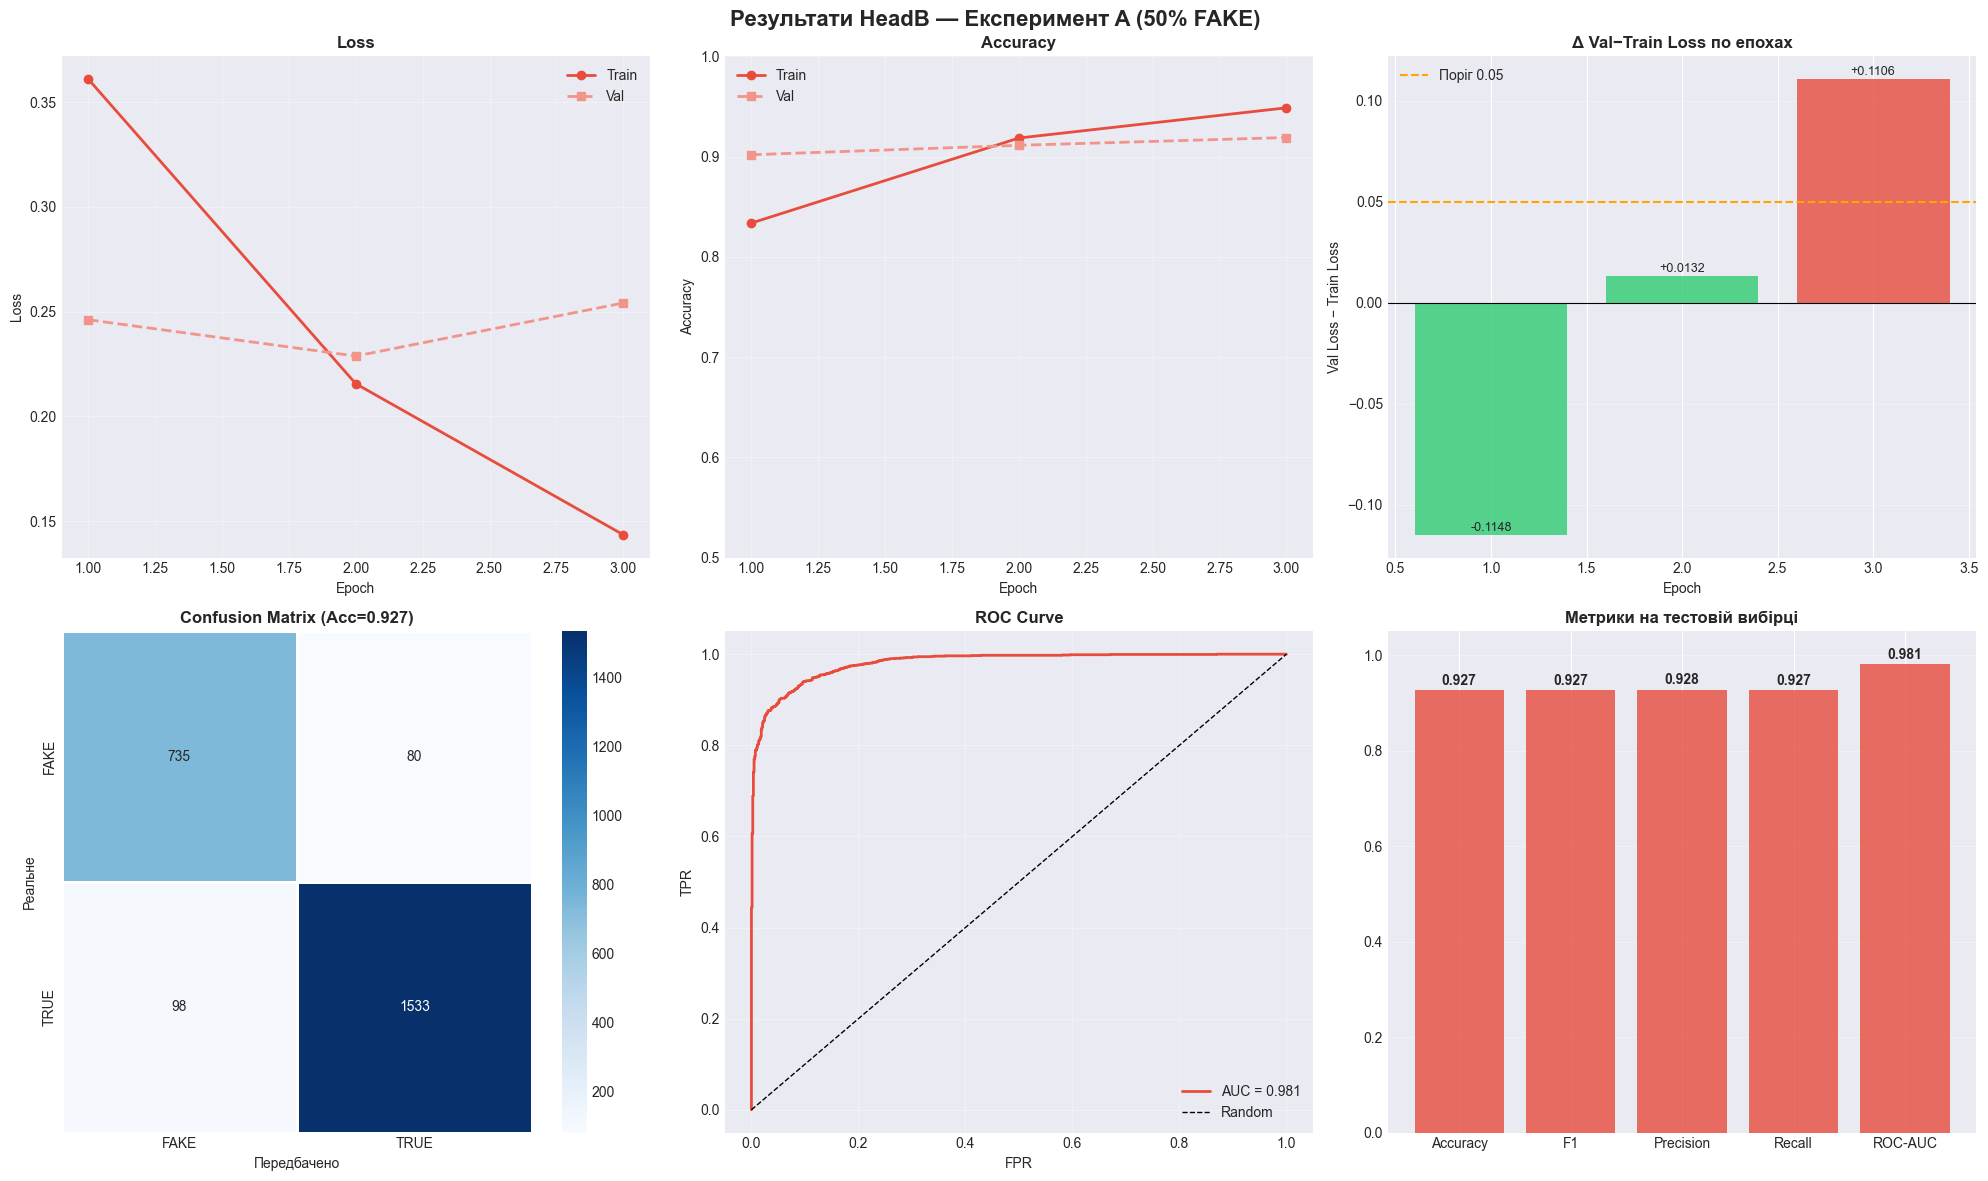

Збережено: plots\03\03_bert_fake_headb_expA_results.png


In [12]:
_, _, _, y_true_b, y_pred_b, y_prob_b = evaluate(model_b, test_loader, criterion)

metrics_b = {
    'acc':     accuracy_score(y_true_b, y_pred_b),
    'f1':      f1_score(y_true_b, y_pred_b, average='weighted'),
    'prec':    precision_score(y_true_b, y_pred_b, average='weighted'),
    'rec':     recall_score(y_true_b, y_pred_b, average='weighted'),
    'roc_auc': roc_auc_score(y_true_b, y_prob_b)
}

print('\nTest Results Head B (ExpA):')
for k, v in metrics_b.items():
    print(f'  {k}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_true_b, y_pred_b, target_names=['FAKE','TRUE'], digits=4))

plot_head_results('HeadB', history_b, y_true_b, y_pred_b, y_prob_b, metrics_b)

## 10. Тренування Head C (ExpA)

In [13]:
torch.cuda.empty_cache(); gc.collect()

print('=' * 60)
print('HEAD C (ExpA): AttentionPooling → Linear(768→256) → LN → ReLU → Dropout → Linear(256→2)')
print('=' * 60)

model_c = BertClassifierHeadC(MODEL_NAME, dropout=DROPOUT_RATE).to(device)
print(f'Параметрів: {sum(p.numel() for p in model_c.parameters()):,}')

model_c, history_c, best_f1_c = train_model(model_c, train_loader, val_loader, 'HeadC')

HEAD C (ExpA): AttentionPooling → Linear(768→256) → LN → ReLU → Dropout → Linear(256→2)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметрів: 178,052,099

Тренування HeadC (ExpA)...
   Кроків warmup: 214 / 2142
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1


     1 |     0.3388 |   0.8400 |   0.2363 |  0.9084 | 0.9079  Δ=-0.1025 ✓ SAVED
         Чекпойнт: checkpoints\HeadC_epoch1_ckpt.pt


     2 |     0.1837 |   0.9275 |   0.2050 |  0.9121 | 0.9130  Δ=+0.0212 ✓ SAVED
         Чекпойнт: checkpoints\HeadC_epoch2_ckpt.pt


     3 |     0.1229 |   0.9543 |   0.2341 |  0.9211 | 0.9209  Δ=+0.1113 ✓ SAVED
         Чекпойнт: checkpoints\HeadC_epoch3_ckpt.pt
Найкращий Val F1: 0.9209



Test Results Head C (ExpA):
  acc: 0.9244
  f1: 0.9244
  prec: 0.9245
  rec: 0.9244
  roc_auc: 0.9814

Classification Report:
              precision    recall  f1-score   support

        FAKE     0.8841    0.8896    0.8869       815
        TRUE     0.9446    0.9418    0.9432      1631

    accuracy                         0.9244      2446
   macro avg     0.9144    0.9157    0.9150      2446
weighted avg     0.9245    0.9244    0.9244      2446



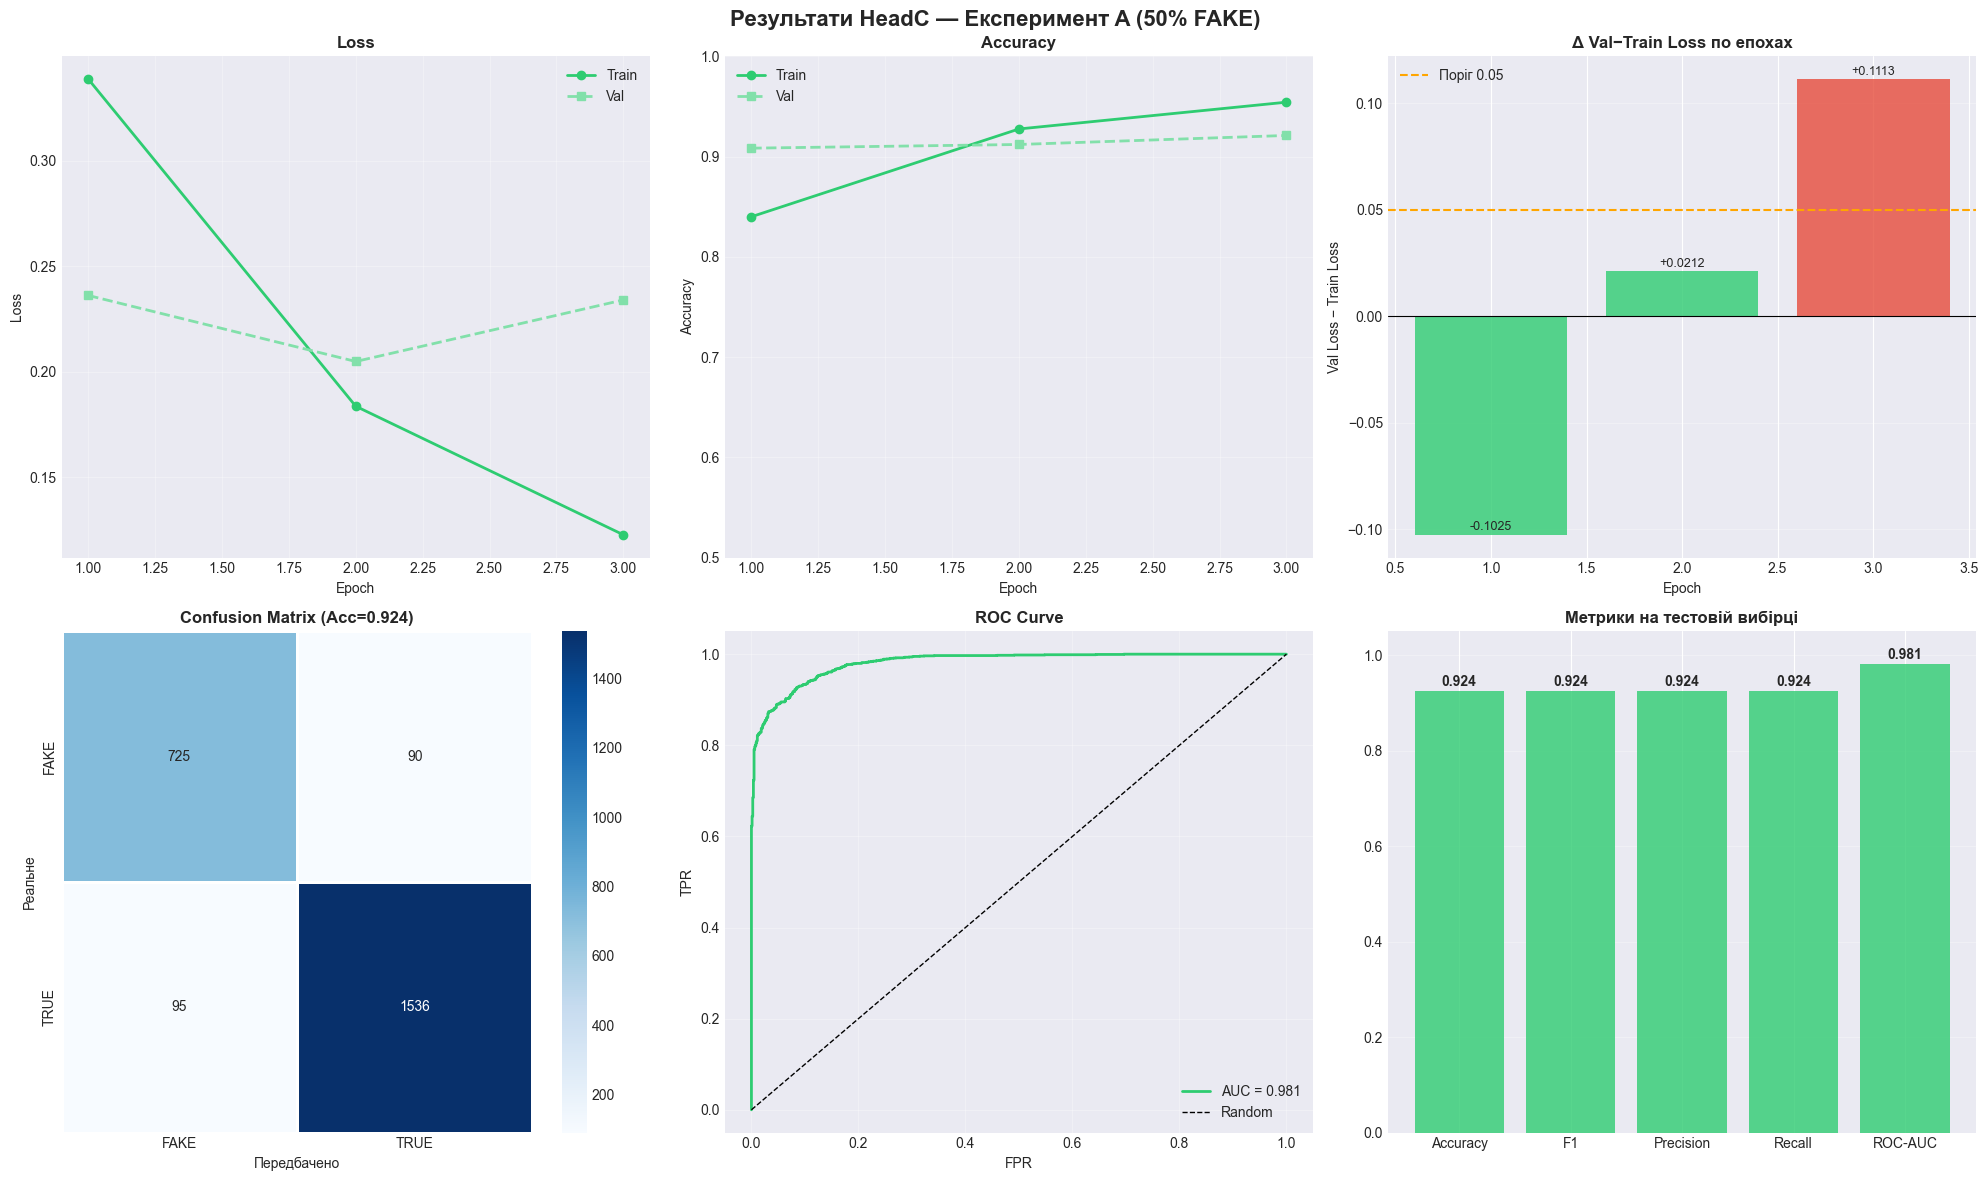

Збережено: plots\03\03_bert_fake_headc_expA_results.png


In [14]:
_, _, _, y_true_c, y_pred_c, y_prob_c = evaluate(model_c, test_loader, criterion)

metrics_c = {
    'acc':     accuracy_score(y_true_c, y_pred_c),
    'f1':      f1_score(y_true_c, y_pred_c, average='weighted'),
    'prec':    precision_score(y_true_c, y_pred_c, average='weighted'),
    'rec':     recall_score(y_true_c, y_pred_c, average='weighted'),
    'roc_auc': roc_auc_score(y_true_c, y_prob_c)
}

print('\nTest Results Head C (ExpA):')
for k, v in metrics_c.items():
    print(f'  {k}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_true_c, y_pred_c, target_names=['FAKE','TRUE'], digits=4))

plot_head_results('HeadC', history_c, y_true_c, y_pred_c, y_prob_c, metrics_c)

## 11. Порівняння та зведені графіки


ПОРІВНЯННЯ РЕЗУЛЬТАТІВ ExpA НА ТЕСТОВОМУ НАБОРІ
Модель                  Accuracy       F1  Precision   Recall  ROC-AUC
--------------------------------------------------------------------------------
Head A (Linear)           0.9203   0.9206     0.9211   0.9203   0.9811
Head B (BN-MLP)           0.9272   0.9274     0.9277   0.9272   0.9807
Head C (AttPool)          0.9244   0.9244     0.9245   0.9244   0.9814


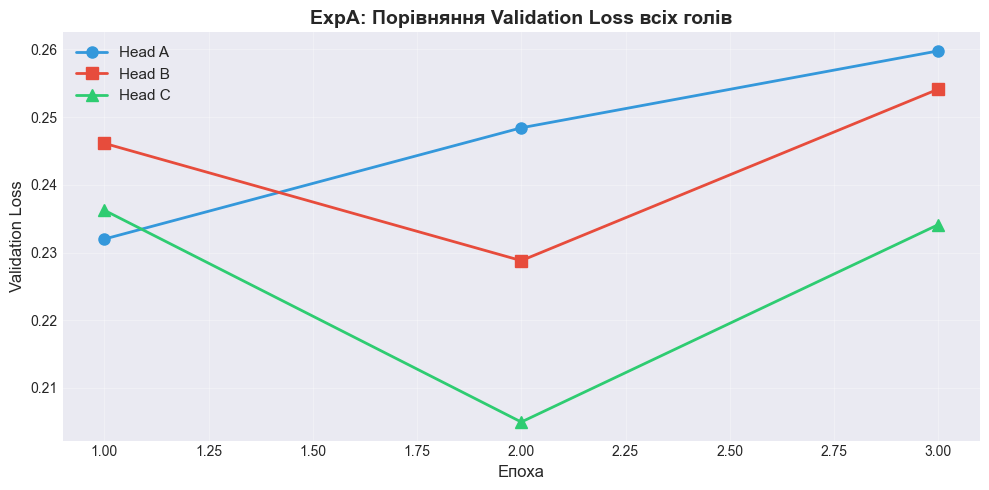

In [15]:
results = {
    'Head A (Linear)':  {**metrics_a, 'y_true': y_true_a, 'y_pred': y_pred_a, 'y_prob': y_prob_a, 'history': history_a},
    'Head B (BN-MLP)':  {**metrics_b, 'y_true': y_true_b, 'y_pred': y_pred_b, 'y_prob': y_prob_b, 'history': history_b},
    'Head C (AttPool)': {**metrics_c, 'y_true': y_true_c, 'y_pred': y_pred_c, 'y_prob': y_prob_c, 'history': history_c},
}

print('\n' + '=' * 80)
print('ПОРІВНЯННЯ РЕЗУЛЬТАТІВ ExpA НА ТЕСТОВОМУ НАБОРІ')
print('=' * 80)
print(f'{"Модель":<22} {"Accuracy":>9} {"F1":>8} {"Precision":>10} {"Recall":>8} {"ROC-AUC":>8}')
print('-' * 80)
for name, r in results.items():
    print(f'{name:<22} {r["acc"]:>9.4f} {r["f1"]:>8.4f} {r["prec"]:>10.4f} {r["rec"]:>8.4f} {r["roc_auc"]:>8.4f}')
print('=' * 80)

# Val Loss всіх трьох на одному графіку
plt.figure(figsize=(10, 5))
epochs_range = range(1, NUM_EPOCHS + 1)
plt.plot(epochs_range, history_a['val_loss'], 'o-', color='#3498db', label='Head A', linewidth=2, markersize=8)
plt.plot(epochs_range, history_b['val_loss'], 's-', color='#e74c3c', label='Head B', linewidth=2, markersize=8)
plt.plot(epochs_range, history_c['val_loss'], '^-', color='#2ecc71', label='Head C', linewidth=2, markersize=8)
plt.xlabel('Епоха', fontsize=12); plt.ylabel('Validation Loss', fontsize=12)
plt.title('ExpA: Порівняння Validation Loss всіх голів', fontsize=14, fontweight='bold')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_expA_val_loss_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

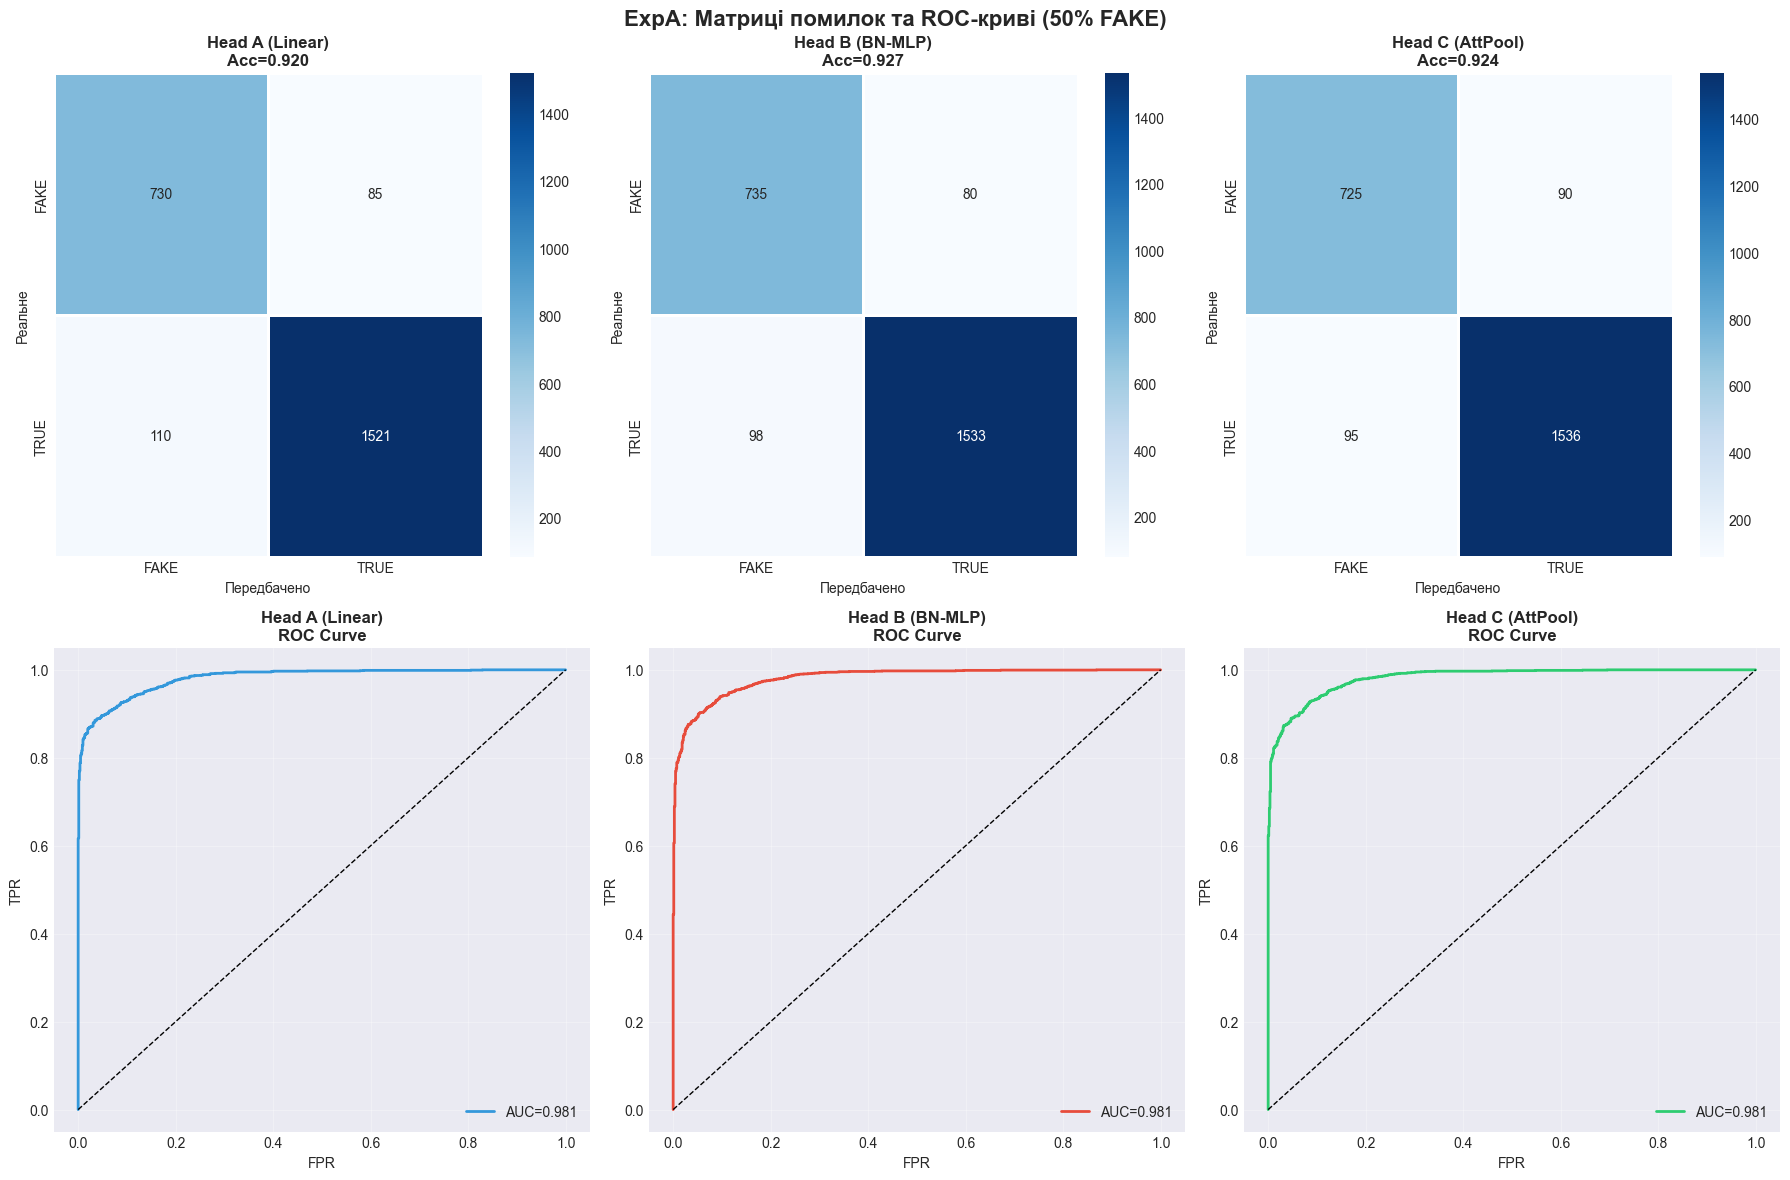

In [16]:
# Confusion Matrix + ROC для всіх голів
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ExpA: Матриці помилок та ROC-криві (50% FAKE)', fontsize=16, fontweight='bold')
colors_list = [('#3498db','Head A (Linear)'), ('#e74c3c','Head B (BN-MLP)'), ('#2ecc71','Head C (AttPool)')]

for col, (color, name) in enumerate(colors_list):
    r = results[name]
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0][col], cmap='Blues',
                xticklabels=['FAKE','TRUE'], yticklabels=['FAKE','TRUE'],
                linewidths=1, linecolor='white')
    axes[0][col].set_title(f'{name}\nAcc={r["acc"]:.3f}', fontweight='bold')
    axes[0][col].set_xlabel('Передбачено'); axes[0][col].set_ylabel('Реальне')

    fpr, tpr, _ = roc_curve(r['y_true'], r['y_prob'])
    axes[1][col].plot(fpr, tpr, color=color, lw=2, label=f'AUC={r["roc_auc"]:.3f}')
    axes[1][col].plot([0,1],[0,1], 'k--', lw=1)
    axes[1][col].set_title(f'{name}\nROC Curve', fontweight='bold')
    axes[1][col].set_xlabel('FPR'); axes[1][col].set_ylabel('TPR')
    axes[1][col].legend(); axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_expA_confusion_roc.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## 12. Збереження результатів

In [17]:
name_map = {
    'Head A (Linear)':  '03_bert_fake_expA_headA_results.json',
    'Head B (BN-MLP)':  '03_bert_fake_expA_headB_results.json',
    'Head C (AttPool)': '03_bert_fake_expA_headC_results.json',
}
head_name_map = {
    'Head A (Linear)':  'BERT_HeadA_ExpA',
    'Head B (BN-MLP)':  'BERT_HeadB_ExpA',
    'Head C (AttPool)': 'BERT_HeadC_ExpA',
}

for name, r in results.items():
    metrics_to_save = {
        'timestamp': datetime.now().isoformat(),
        'metrics': {
            'accuracy':  float(r['acc']),
            'precision': float(r['prec']),
            'recall':    float(r['rec']),
            'f1':        float(r['f1']),
            'roc_auc':   float(r['roc_auc'])
        },
        'model_name': head_name_map[name],
        'experiment': 'ExpA_50pct_FAKE',
        'dataset_info': {
            'true_count': int(true_count),
            'fake_count': int(fake_count),
            'total':      int(len(df))
        }
    }
    filepath = os.path.join(RESULTS_DIR, name_map[name])
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)
    print(f'Збережено: {filepath}')

best_name  = max(results, key=lambda k: results[k]['f1'])

print('\n' + '=' * 80)
print('ПІДСУМКОВА ТАБЛИЦЯ ExpA')
print('=' * 80)
print(f'{"Модель":<35} {"Acc":>7} {"F1":>7} {"Prec":>7} {"Rec":>7} {"AUC":>7}  Статус')
print('-' * 80)
for name, r in results.items():
    flag = 'НАЙКРАЩЕ ✓' if name == best_name else ''
    print(f'{"BERT " + name + " (ExpA)":<35} {r["acc"]:>7.4f} {r["f1"]:>7.4f} {r["prec"]:>7.4f} {r["rec"]:>7.4f} {r["roc_auc"]:>7.4f}  {flag}')
print('=' * 80)
print(f'\nЗбережено в {PLOTS_DIR}/ та {RESULTS_DIR}/')
print(f'Чекпойнти: {CHECKPOINTS_DIR}/')
print('\nДля продовження навчання з епохи N:')
print('  model_a, history_a, best_f1_a = train_model(model_a, ..., resume_from_epoch=N)')

Збережено: results\03_bert_fake_expA_headA_results.json
Збережено: results\03_bert_fake_expA_headB_results.json
Збережено: results\03_bert_fake_expA_headC_results.json

ПІДСУМКОВА ТАБЛИЦЯ ExpA
Модель                                  Acc      F1    Prec     Rec     AUC  Статус
--------------------------------------------------------------------------------
BERT Head A (Linear) (ExpA)          0.9203  0.9206  0.9211  0.9203  0.9811  
BERT Head B (BN-MLP) (ExpA)          0.9272  0.9274  0.9277  0.9272  0.9807  НАЙКРАЩЕ ✓
BERT Head C (AttPool) (ExpA)         0.9244  0.9244  0.9245  0.9244  0.9814  

Збережено в plots\03/ та results/
Чекпойнти: checkpoints/

Для продовження навчання з епохи N:
  model_a, history_a, best_f1_a = train_model(model_a, ..., resume_from_epoch=N)
